In [1]:
pairs=[]
with open('/content/fra.txt', 'r', encoding='utf-8') as f:
    for line in f:
        t=line.strip().split('\t')
        if len(t)>=2:
            pairs.append((t[0], t[1]))
pairs=list(set(pairs))
print(f'всего пар: {len(pairs)}')
print(pairs[:5])

всего пар: 9123
[('Can you help?', 'Pouvez-vous aider ?'), ('Take care!', 'Faites attention.'), ('I could help.', 'Je pouvais aider.'), ('Do I look fat?', "Ai-je l'air gros ?"), ("I'm exhausted.", 'Je suis épuisée.')]


In [2]:
from sklearn.model_selection import train_test_split

train, val=train_test_split(pairs, test_size=0.1, random_state=42)

print(f'train: {len(train)}')
print(f'val: {len(val)}')

train: 8210
val: 913


In [3]:
src_words = set()
for eng, fra in pairs:
    for w in eng.split():
        src_words.add(w.lower())

src_w_i = {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3}
for w in src_words:
    if w not in src_w_i:
        src_w_i[w] = len(src_w_i)
src_i_w = {v: k for k, v in src_w_i.items()}

tgt_words = set()
for eng, fra in pairs:
    for w in fra.split():
        tgt_words.add(w.lower())

tgt_w_i = {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3}
for w in tgt_words:
    if w not in tgt_w_i:
        tgt_w_i[w] = len(tgt_w_i)
tgt_i_w = {v: k for k, v in tgt_w_i.items()}

print(f"английский словарь: {len(src_w_i)}")
print(f"французский словарь: {len(tgt_w_i)}")

английский словарь: 2573
французский словарь: 5081


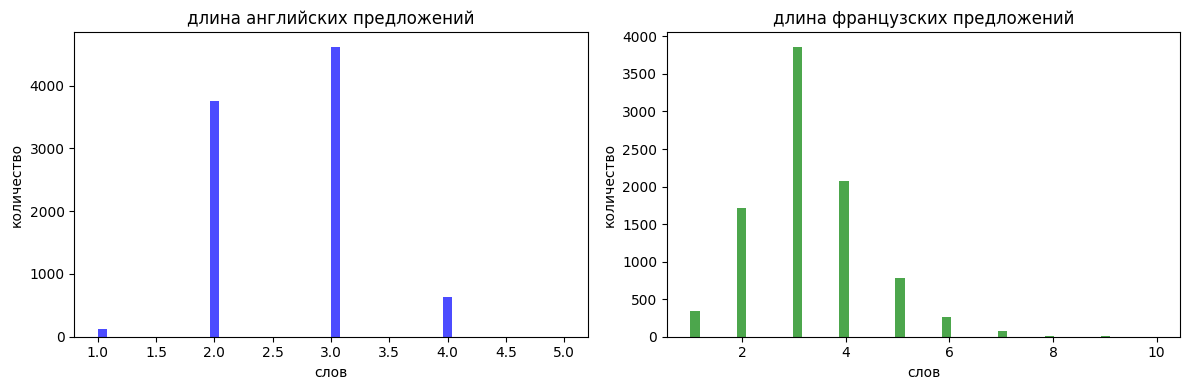

In [4]:
import matplotlib.pyplot as plt

src_len = [len(eng.split()) for eng, _ in pairs]
tgt_len = [len(fra.split()) for _, fra in pairs]

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(src_len, bins=50, color='blue', alpha=0.7)
plt.title('длина английских предложений')
plt.xlabel('слов')
plt.ylabel('количество')

plt.subplot(1,2,2)
plt.hist(tgt_len, bins=50, color='green', alpha=0.7)
plt.title('длина французских предложений')
plt.xlabel('слов')
plt.ylabel('количество')

plt.tight_layout()

In [5]:
import torch
from torch.utils.data import DataLoader, Dataset

def sentence_i(sentence, w_i, max_len=8):
    words = sentence.split()
    idxs = [w_i.get(w.lower(), w_i['<UNK>']) for w in words]

    # обрезаем, если длиннее max_len-2 (для SOS и EOS)
    if len(idxs) > max_len - 2:
        idxs = idxs[:max_len-2]

    idxs = [w_i['<SOS>']] + idxs + [w_i['<EOS>']]

    # добавляем PAD до max_len
    if len(idxs) < max_len:
        idxs += [w_i['<PAD>']] * (max_len - len(idxs))

    return torch.tensor(idxs)

class TranslateDataset(Dataset):
  def __init__(self, pairs, src_wi, tgt_wi, max_len=40):
    self.pairs=pairs
    self.src_wi=src_wi
    self.tgt_wi=tgt_wi
    self.max_len=max_len

  def __len__(self):
    return len(self.pairs)

  def __getitem__(self,i):
    src, tgt=self.pairs[i]
    src_tensor=sentence_i(src, self.src_wi, self.max_len)
    tgt_tensor=sentence_i(tgt, self.tgt_wi, self.max_len)
    return src_tensor, tgt_tensor


train_dataset = TranslateDataset(train, src_w_i, tgt_w_i, 40)
val_dataset = TranslateDataset(val, src_w_i, tgt_w_i, 40)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

print(f'батчей train: {len(train_loader)},\nбатчей val: {len(val_loader)}')

батчей train: 65,
батчей val: 8


In [6]:
import numpy as np
from torch.nn import Module, LSTM, Dropout, Linear, Embedding

class Encoder(Module):
  def __init__(self, vocab_size, embed_size, hidden_size):
    super().__init__()
    self.embedding=Embedding(vocab_size, embed_size)
    self.lstm=LSTM(embed_size, hidden_size, num_layers=2, batch_first=True, bidirectional=True)
    self.dropout=Dropout(0.6)
    self.fc_hidden=Linear(hidden_size*2, hidden_size)
    self.fc_cell=Linear(hidden_size*2, hidden_size)


  def forward(self, x):
    x=self.embedding(x)
    x=self.dropout(x)
    outputs, (hidden, cell)=self.lstm(x)

    hidden=torch.cat((hidden[0], hidden[1]), dim=1) # (batch, hidden_size*2)
    cell=torch.cat((cell[0], cell[1]), dim=1) # (batch, hidden_size*2)

    hidden=self.fc_hidden(hidden).unsqueeze(0)  # (1, batch, hidden_size)
    cell=self.fc_cell(cell).unsqueeze(0)  # (1, batch, hidden_size)

    return outputs, hidden, cell


class Attention(Module):
  def __init__(self, hidden_size):
    super().__init__()
    self.attn=Linear(hidden_size*3, 1)

  def forward(self, hidden, encoder_outputs):
    hidden=hidden.permute(1,0,2)

    #копируем для каждого слова
    hidden=hidden.repeat(1,encoder_outputs.shape[1], 1)

    #объединяем и вычисляем веса
    x=torch.cat((hidden, encoder_outputs), dim=2)
    weights=self.attn(x).squeeze(2)

    return torch.softmax(weights, dim=1)



class Decoder(Module):
  def __init__(self,vocab_size, embed_size, hidden_size):
    super().__init__()
    self.embedding=Embedding(vocab_size, embed_size)
    self.attention=Attention(hidden_size)
    self.lstm=LSTM(embed_size+hidden_size*2, hidden_size, batch_first=True)
    self.fc_out=Linear(hidden_size*3 + embed_size, vocab_size)
    self.dropout=Dropout(0.6)

  def forward(self, input, hidden, cell, encoder_outputs):
    #input: (batch,)
    input=input.unsqueeze(1)
    input=self.dropout(self.embedding(input)) #(batch,1,embed_size)

    #внимание
    a=self.attention(hidden, encoder_outputs).unsqueeze(1) # (batch,1,src_len)
    w=torch.bmm(a, encoder_outputs) # (batch, 1, hidden_size*2)

    # lstm
    x=torch.cat((input,w),2) # (batch, 1, embed_size + hidden_size*2)
    output, (hidden, cell)=self.lstm(x, (hidden,cell))

    #предсказание
    output=output.squeeze(1) # (batch, hidden_size)
    w=w.squeeze(1) # (batch, hidden_size*2)
    input=input.squeeze(1) # (batch, embed_size)

    x=torch.cat((output, w, input), dim=1)  # (batch, hidden_size + hidden_size*2 + embed_size)

    return self.fc_out(x), hidden, cell


device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class Seq2Seq(Module):
  def __init__(self, encoder, decoder, device):
    super().__init__()
    self.encoder=encoder
    self.decoder=decoder
    self.device=device

  def forward(self, src,tgt, teacher_forcing_ratio=0.5):
    batch_size=src.shape[0]
    tgt_len=tgt.shape[1]
    tgt_vocab_size=self.decoder.fc_out.out_features # получаем размер словаря целевого языка из выходного слоя декодера

    # тензор из нулей, куда будем складывать предсказания модели на каждом шаге
    outputs=torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)

    # кодируем исходное предложение
    encoder_outputs, hidden, cell= self.encoder(src)

    input=tgt[:,0]

    # генерируем перевод по словам
    for t in range(1, tgt_len):
      output, hidden, cell= self.decoder(input, hidden, cell, encoder_outputs)
      outputs[:,t,:]=output

      # с вероятностью teacher_forcing_ratio используем правильное слово
      if np.random.random() < teacher_forcing_ratio:
        input = tgt[:, t] # берем правильное слово
      else:
        input = output.argmax(1) # берем предсказание

    return outputs

In [7]:
from tqdm import tqdm

encoder=Encoder(len(src_w_i), 512, 1024)
decoder=Decoder(len(tgt_w_i), 512, 1024)

model=Seq2Seq(encoder, decoder, device).to(device)

optimizer=torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)
scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
loss_f=torch.nn.CrossEntropyLoss()

best_val_loss=float('inf')
patience=5
patience_counter=0

train_losses = []
val_losses = []

for epoch in range(50):
  model.train()
  train_loss=0
  for src, tgt in tqdm(train_loader, desc=f'epoch {epoch+1} train'):
    src, tgt=src.to(device), tgt.to(device)
    optimizer.zero_grad()
    output=model(src, tgt)

    # изменяем форму, чтобы loss сравнивал каждое слово отдельно
    loss=loss_f(output.view(-1,len(tgt_w_i)), tgt.view(-1))
    train_loss+=loss.item()

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
    optimizer.step()

  model.eval()
  val_loss=0
  with torch.no_grad():
    for src, tgt in tqdm(val_loader, desc=f'epoch {epoch+1} val'):
      src, tgt= src.to(device), tgt.to(device)
      output=model(src, tgt, teacher_forcing_ratio=0)
      loss=loss_f(output.view(-1,len(tgt_w_i)), tgt.view(-1))
      val_loss+=loss.item()

  avg_train_loss=train_loss/len(train_loader)
  avg_val_loss=val_loss/len(val_loader)

  train_losses.append(avg_train_loss)
  val_losses.append(avg_val_loss)

  scheduler.step(avg_val_loss)

  print(f"epoch {epoch+1}: train Loss = {avg_train_loss:.3f}, val Loss = {avg_val_loss:.3f}")

  if avg_val_loss<best_val_loss:
    best_val_loss=avg_val_loss
    torch.save(model.state_dict(), 'best_model_translate.pth')
  else:
    patience_counter += 1
    if patience_counter >= patience:
      print(f"ранняя остановка на эпохе {epoch+1}")
      break

epoch 1 val: 100%|██████████| 8/8 [00:02<00:00,  3.38it/s]


epoch 1: train Loss = 1.420, val Loss = 0.805


epoch 2 val: 100%|██████████| 8/8 [00:02<00:00,  3.28it/s]


epoch 2: train Loss = 0.771, val Loss = 0.789


epoch 3 val: 100%|██████████| 8/8 [00:02<00:00,  3.18it/s]


...

epoch 24: train Loss = 0.377, val Loss = 0.584


epoch 25 val: 100%|██████████| 8/8 [00:02<00:00,  3.02it/s]


epoch 25: train Loss = 0.360, val Loss = 0.579


epoch 26 val: 100%|██████████| 8/8 [00:02<00:00,  3.03it/s]

epoch 26: train Loss = 0.353, val Loss = 0.580
ранняя остановка на эпохе 26


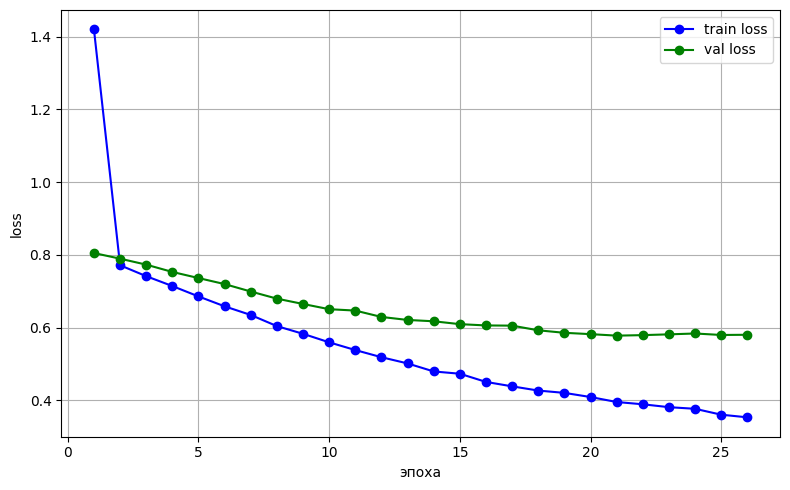

In [8]:
epochs = list(range(1, len(train_losses)+1))

plt.figure(figsize=(8,5))

plt.plot(epochs, train_losses, 'b-o', label='train loss')
plt.plot(epochs, val_losses, 'g-o', label='val loss')

plt.xlabel('эпоха')
plt.ylabel('loss')
plt.legend()
plt.grid(True)

plt.tight_layout()

In [9]:
model.load_state_dict(torch.load('best_model_translate.pth'))
model.eval()

def translate(text, max_len=32):
  with torch.no_grad():
    tokens=sentence_i(text, src_w_i, max_len).unsqueeze(0).to(device)
    encoder_outputs, hidden, cell=model.encoder(tokens)
    input=torch.tensor([tgt_w_i['<SOS>']]).to(device)
    translated=[]
    for i in range(max_len):
      output, hidden, cell= model.decoder(input, hidden, cell, encoder_outputs)
      pred=output.argmax(1).item()
      if pred==tgt_w_i['<EOS>']:
        break
      if pred not in [tgt_w_i['<PAD>'], tgt_w_i['<SOS>']]:
        translated.append(tgt_i_w[pred])

      input=torch.tensor([pred]).to(device)
    return ' '.join(translated)

test_phrases = [
    "I want to go to the store",
    "I was very tired",
    "I'd like to talk to you",
    "I'm looking forward to seeing you",
    "I don't know what to do"
]

print("переводы:")
for phrase in test_phrases:
    print(f'англ: {phrase}')
    print(f'франц: {translate(phrase)}\n')

переводы:
англ: I want to go to the store
франц: je veux au travail.

англ: I was very tired
франц: j'étais été

англ: I'd like to talk to you
франц: il me faut

англ: I'm looking forward to seeing you
франц: je ne peux pas un

англ: I don't know what to do
франц: je dois y



In [ ]:
from transformers import T5Tokenizer, T5ForConditionalGeneration

class T5TranslateDataset(Dataset):
    def __init__(self, pairs, tokenizer, max_len=32):
        self.pairs = pairs
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, i):
        src, tgt = self.pairs[i]
        src_enc = self.tokenizer(src, max_length=self.max_len, truncation=True, padding='max_length', return_tensors='pt')
        tgt_enc = self.tokenizer(tgt, max_length=self.max_len, truncation=True, padding='max_length', return_tensors='pt')
        return {
            'input_ids': src_enc['input_ids'][0],
            'attention_mask': src_enc['attention_mask'][0],
            'labels': tgt_enc['input_ids'][0]
        }

tokenizer_t5 = T5Tokenizer.from_pretrained('t5-small')
model_t5 = T5ForConditionalGeneration.from_pretrained('t5-small').to(device)

train_dataset_t5 = T5TranslateDataset(train, tokenizer_t5, max_len=32)
val_dataset_t5 = T5TranslateDataset(val, tokenizer_t5, max_len=32)

train_loader_t5 = DataLoader(train_dataset_t5, batch_size=32, shuffle=True)
val_loader_t5 = DataLoader(val_dataset_t5, batch_size=32, shuffle=False)

optimizer_t5 = torch.optim.Adam(model_t5.parameters(), lr=3e-4)
loss_f_t5 = torch.nn.CrossEntropyLoss(ignore_index=tokenizer_t5.pad_token_id)

best_val_loss=float('inf')
patience=3
patience_counter=0

train_losses_t5=[]
val_losses_t5=[]

for epoch in range(10):
    model_t5.train()
    train_loss = 0
    for batch in tqdm(train_loader_t5, desc=f'epoch {epoch+1} train'):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer_t5.zero_grad()
        outputs = model_t5(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        train_loss += loss.item()

        loss.backward()
        optimizer_t5.step()

    model_t5.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in tqdm(val_loader_t5, desc=f'epoch {epoch+1} val'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model_t5(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            val_loss += outputs.loss.item()

    avg_train_loss = train_loss / len(train_loader_t5)
    avg_val_loss = val_loss / len(val_loader_t5)

    train_losses_t5.append(avg_train_loss)
    val_losses_t5.append(avg_val_loss)

    print(f"epoch {epoch+1}: train Loss = {avg_train_loss:.3f}, val Loss = {avg_val_loss:.3f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model_t5.state_dict(), 'best_model_t5.pth')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"ранняя остановка на эпохе {epoch+1}")
            break

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

epoch 8: train Loss = 0.125, val Loss = 0.152


epoch 9 val: 100%|██████████| 108/108 [00:05<00:00, 20.09it/s]


epoch 9: train Loss = 0.118, val Loss = 0.151


epoch 10 val: 100%|██████████| 108/108 [00:05<00:00, 19.99it/s]


epoch 10: train Loss = 0.112, val Loss = 0.150


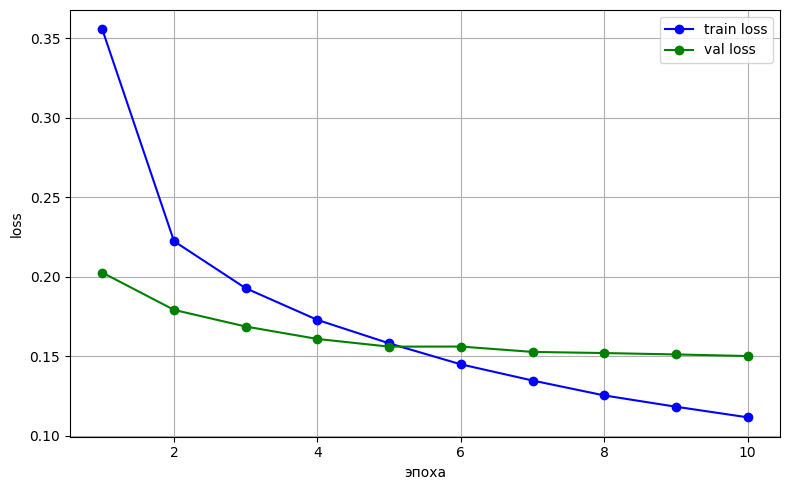

In [ ]:
epochs_t5 = list(range(1, len(train_losses_t5) + 1))

plt.figure(figsize=(8,5))
plt.plot(epochs_t5, train_losses_t5, 'b-o', label='train loss')
plt.plot(epochs_t5, val_losses_t5, 'g-o', label='val loss')
plt.xlabel('эпоха')
plt.ylabel('loss')
plt.legend()
plt.grid(True)
plt.tight_layout()

In [ ]:
model_t5.load_state_dict(torch.load('best_model_t5.pth'))
model_t5.eval()

def translate_t5(text, max_len=32):
    inputs = tokenizer_t5(text, return_tensors='pt', max_length=32, truncation=True).to(device)
    with torch.no_grad():
        outputs = model_t5.generate(**inputs, max_length=max_len)
    return tokenizer_t5.decode(outputs[0], skip_special_tokens=True)

print("переводы T5:")
for phrase in test_phrases:
    print(f'англ: {phrase}')
    print(f'франц: {translate_t5(phrase)}\n')

переводы T5:
англ: I want to go to the store
франц: Je veux aller au magasin.

англ: I was very tired
франц: J'étais très fatiguée.

англ: I'd like to talk to you
франц: Je t'aimerais te parler.

англ: I'm looking forward to seeing you
франц: J'espère te voir.

англ: I don't know what to do
франц: Je ne sais pas quoi faire.



In [ ]:
import pickle
from google.colab import files

torch.save(model_t5.state_dict(), 'best_model_t5.pth')

files.download('best_model_t5.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>